<p class="mlx-kicker">Part IV &middot; Beyond the block &middot; Chapter 14</p>

# 14. Inference and use: from greedy decoding to reasoning and tools

<dl class="mlx-meta"><div><dt>Level</dt><dd>Intermediate</dd></div><div><dt>Reading</dt><dd>about 25 min</dd></div><div><dt>Hands-on</dt><dd>about 7 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 1, and next-token prediction (chapter 8)</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/transformer-explained/blob/main/chapters/14-inference/index.ipynb)

![Three generations of using a trained model. Decoding picks one token per forward pass and caches what it has already computed; chain of thought writes intermediate tokens that later passes read back, so the serial computation grows with the length of the answer; test-time search samples many chains, keeps the one a verifier accepts, and hands exact work to tools.](figures/inference-lineage.svg)

## What changed, and why it works

Every earlier chapter changed how a model is built or trained. This one leaves the weights alone and asks what happens when the model is *used*. A language model only ever outputs a probability distribution over the next token. Everything else, from a single sentence to a long reasoning trace that calls a calculator, is a procedure wrapped around that one forward pass. The guiding question of the chapter is: **why does thinking longer help?** The short answer is that a Transformer does a fixed amount of serial computation per token, so the only way to let it compute more for a given question is to let it write more tokens. Figure 14.1 shows the three generations of using that fact.

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; Decoding</p><h3>Sampling knobs and a KV cache</h3><p><b>What changed.</b> Instead of always taking the most likely next token (greedy), the decoder samples from a reshaped distribution: temperature flattens or sharpens it, top-k and top-p cut off its unreliable tail. A KV cache stores each past token's keys and values so that only the new token is computed.</p><p><b>Why it works.</b> The most likely token at each step does not give the most likely or most natural text: greedy decoding falls into loops because a repeated phrase makes itself more probable. Sampling escapes the loop, and truncating the tail removes the many rare tokens whose combined probability would otherwise produce nonsense. The cache works because a causal model's past keys and values never change, so recomputing them is pure waste.</p><p class="mlx-why__run">Our runs: 1% of greedy 8-grams are distinct, 100% at T = 1; the cache is 7.8&times; faster at 1,024 tokens</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; Chain of thought</p><h3>Intermediate tokens as working memory</h3><p><b>What changed.</b> The model is trained or prompted to write the intermediate steps of a problem before the answer (scratchpads, Nye et al., 2021; chain-of-thought prompting, Wei et al., 2022).</p><p><b>Why it works.</b> One forward pass is a fixed-depth circuit: with L layers, the answer can depend on at most L serial steps of computation. Each written token is fed back in as input, so the next pass starts from a result the previous pass already computed. Writing k steps turns an L-step budget into roughly L &times; k, and each individual step becomes a small, local problem.</p><p class="mlx-why__run">Our run: a running sum of 8 digits, 2-layer model: 10% correct answering directly (chance), 100% writing the steps</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; Search and tools</p><h3>Sample many, verify, call a tool</h3><p><b>What changed.</b> Inference became a search: sample many reasoning chains and take a majority vote (self-consistency, Wang et al., 2022) or keep one a verifier accepts, train models to write long traces (2024), and let the model call tools such as a calculator or a search engine (ReAct, 2022; Toolformer, 2023).</p><p><b>Why it works.</b> If one sample is right with probability p and samples fail in different ways, the right answer becomes the most common one, and at least one of N samples is right with probability close to 1 &minus; (1 &minus; p)<sup>N</sup>. Checking an answer is often easier than producing it, so a verifier turns that coverage into accuracy. A tool does exact work that the network would otherwise have to approximate.</p><p class="mlx-why__run">Our runs: one noisy sample 30%, vote of 32 94%, verifier over 32 100%; with a calculator 100%</p></section>
</div>

Read left to right, the unit of inference grows: one token, then one chain of tokens, then many chains and calls to the outside world. At each step more compute is spent per question, and the steps below measure how much each kind of extra compute buys.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 2017 onward | Greedy and beam search with a KV cache | minor | the first Transformer decoders cache past keys and values so each new token costs one pass |
| 2018-2020 | Top-k and nucleus (top-p) sampling | minor | sample from a truncated distribution instead of taking the argmax |
| 2021 | Scratchpads and trained verifiers | **major** | models write intermediate steps; a second model scores whole solutions |
| 2022 | Chain-of-thought prompting, self-consistency | **major** | "think step by step" emerges in large models; voting over sampled chains |
| 2022-2023 | ReAct, Toolformer | **major** | the model emits tool calls and the harness inserts the results |
| 2024-2026 | Long reasoning traces trained with reinforcement learning, agents | **major** | models learn to think for thousands of tokens; accuracy scales with test-time compute |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| greedy to sampling with top-k and top-p | greedy and beam search text was repetitive and bland | varied, natural text with a knob for how adventurous it is |
| recompute to KV cache | generation cost grew with the square of the length | one pass per new token, at the price of memory |
| direct answer to chain of thought | fixed depth limits how many serial steps one pass can do | serial computation that grows with the length of the answer |
| one chain to many chains with a verifier | a single sampled chain is often wrong | accuracy that keeps rising as more compute is spent at test time |
| everything in the weights to tool calls | arithmetic, lookup and fresh facts are hard to store in weights | exact results from the tool, and a model that only has to know when to ask |

Read top to bottom, the pressure moves from *text quality*, to *cost*, to *the limits of a fixed-depth network*. The last three rows share one idea: a model can be made more capable after training by spending more compute when it is used. This made test-time compute a second scaling axis next to model size (Snell et al., 2024), and it is why current frontier models are trained to produce long reasoning traces (OpenAI o1, 2024; DeepSeek-R1, 2025).

**Still open:** how faithful a written chain of thought is to the computation that actually produces the answer; when it is better to spend compute on a larger model than on longer thinking; and how to verify answers in domains with no exact checker, where a learned verifier can be fooled by the model it is checking.

## Run it yourself

The steps share this setup. Step 1 uses a small character model of TinyShakespeare to compare decoding rules and to build a KV cache. Steps 2 to 4 train tiny Transformers on a synthetic arithmetic task, where we can check every answer exactly. Everything runs on a laptop CPU in about seven minutes.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/transformer-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
import collections, math, random, re, time
from mlexp.transformer import TransformerLM

torch.set_num_threads(1)
tok, train_ids, val_ids = mlexp.load_char_corpus()

### Step 1 (major): decoding, one token at a time

#### The idea

A trained language model maps a prefix to a probability for every possible next token. To produce text, a **decoder** repeats three moves: run the model, pick one token from the distribution, append it. The model is fixed; the decoder decides how the distribution is turned into a choice.

- **Greedy** takes the most likely token every time. It is deterministic and, as we will see, prone to loops.
- **Temperature** `\(T\)` divides the logits before the softmax. `\(T < 1\)` sharpens the distribution towards greedy, `\(T > 1\)` flattens it towards uniform.
- **Top-k** (Fan et al., 2018) keeps only the `\(k\)` most likely tokens and renormalizes.
- **Top-p**, or nucleus sampling (Holtzman et al., 2020), keeps the smallest set of tokens whose probabilities add up to `\(p\)`. When the model is confident the set is small; when it is unsure the set is large.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: temperature and nucleus sampling</p><div class="mlx-eq">$$p_T(i) = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}, \qquad V_p = \text{the smallest set of tokens with} \sum_{i \in V_p} p_T(i) \ge p$$</div><p class="mlx-eq__where">\(z_i\) are the logits. The next token is drawn from \(p_T\) restricted to \(V_p\) and renormalized; \(T \to 0\) recovers greedy decoding.</p></div>

#### Minimal implementation

One function turns a row of logits into a chosen token. Everything else in this chapter, from voting to tool calls, is built on top of it.

In [3]:
def pick(logits, temperature=1.0, top_k=None, top_p=None, generator=None):
    """Choose the next token from a (batch, vocab) tensor of logits."""
    if temperature == 0:
        return logits.argmax(-1, keepdim=True)  # greedy
    logits = logits / temperature
    if top_k:  # keep the k largest logits
        kth = logits.topk(top_k, dim=-1).values[..., -1:]
        logits = logits.masked_fill(logits < kth, float("-inf"))
    if top_p:  # keep the smallest set of tokens whose probability reaches top_p
        probs, order = logits.softmax(-1).sort(-1, descending=True)
        drop = probs.cumsum(-1) - probs > top_p  # tokens after the nucleus is already full
        logits = logits.masked_fill(drop.scatter(-1, order, drop), float("-inf"))
    return torch.multinomial(logits.softmax(-1), 1, generator=generator)

We need a model to decode from. This is the chapter 1 architecture, slightly smaller, trained for about a minute on TinyShakespeare with a context of 64 characters.

In [4]:
torch.manual_seed(0)
char_lm = TransformerLM(tok.vocab_size, dim=96, n_layers=3, n_heads=4)
start = time.time()
hist = mlexp.train_lm(char_lm, train_ids, val_ids, steps=500, block_size=64, eval_every=100, log=False)
char_lm.eval()
print(f"{mlexp.count_params(char_lm):,} parameters, val loss {hist['val'][-1]:.3f}, trained in {time.time() - start:.0f}s")

344,928 parameters, val loss 1.817, trained in 57s


#### The KV cache

The simplest decoder runs the whole prefix through the model again for every new token. That is wasteful. In a causal model, token `\(t\)`'s keys and values depend only on tokens up to `\(t\)`, so they never change once computed. A **KV cache** stores them, and each step runs only the newest token through the network: its query attends to the cached keys and values plus its own. Generating `\(n\)` tokens then costs `\(n\)` single-token passes instead of passes over prefixes of length 1, 2, ..., `\(n\)`, whose total work grows with `\(n^2\)`.

The function below reuses the weights of `TransformerLM` unchanged. The only subtlety is position: RoPE (chapter 3) must rotate the new token by its true position in the sequence, not by 0.

In [5]:
def rope_at(x, start):
    """RoPE as in mlexp.transformer.apply_rope, but for positions start, start+1, ..."""
    T, dim = x.shape[-2], x.shape[-1]
    half = dim // 2
    freqs = 10000 ** (-torch.arange(half) / half)
    angles = torch.arange(start, start + T)[:, None] * freqs[None, :]
    cos, sin = angles.cos(), angles.sin()
    x1, x2 = x[..., :half], x[..., half:]
    return torch.cat([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1)


@torch.no_grad()
def forward_cached(model, idx, cache=None):
    """Run only the new tokens idx through the model; cache holds (keys, values) for each layer."""
    start = cache[0][0].shape[2] if cache else 0
    x = model.embed(idx)
    B, T, C = x.shape
    new_cache = []
    for i, block in enumerate(model.blocks):
        attn, H = block.attn, block.attn.n_heads
        q, k, v = attn.qkv(block.norm1(x)).split(C, dim=-1)
        q, k, v = (t.view(B, T, H, C // H).transpose(1, 2) for t in (q, k, v))
        q, k = rope_at(q, start), rope_at(k, start)
        if cache:  # prepend the stored keys and values of all earlier tokens
            k = torch.cat([cache[i][0], k], dim=2)
            v = torch.cat([cache[i][1], v], dim=2)
        new_cache.append((k, v))
        y = F.scaled_dot_product_attention(q, k, v, is_causal=(start == 0 and T > 1))
        x = x + attn.out(y.transpose(1, 2).reshape(B, T, C))
        x = x + block.ffn(block.norm2(x))
    return model.head(model.norm(x)), new_cache


@torch.no_grad()
def generate(model, idx, n_new, use_cache=True, **pick_args):
    """Append n_new tokens to every row of idx (batch, length)."""
    cache, new = None, idx
    for _ in range(n_new):
        if use_cache:
            logits, cache = forward_cached(model, new, cache)
        else:
            logits, _ = model(idx)  # recompute the whole prefix every time
        new = pick(logits[:, -1], **pick_args)
        idx = torch.cat([idx, new], dim=1)
    return idx


prompt = tok.encode("ROMEO:\n")[None]
same = torch.equal(generate(char_lm, prompt, 100, use_cache=False, temperature=0),
                   generate(char_lm, prompt, 100, use_cache=True, temperature=0))
print("cached and uncached greedy outputs identical:", same)

cached and uncached greedy outputs identical: True


#### Experiment: what the cache saves

We time greedy generation of 128 to 1,024 tokens with and without the cache. The model was trained on 64-character windows, so the long outputs are not good text; here we only measure cost.

  128 tokens: recompute  0.36s, KV cache 0.18s, speedup 1.9x


  256 tokens: recompute  1.04s, KV cache 0.45s, speedup 2.3x


  512 tokens: recompute  3.55s, KV cache 0.86s, speedup 4.1x


 1024 tokens: recompute 14.47s, KV cache 1.86s, speedup 7.8x


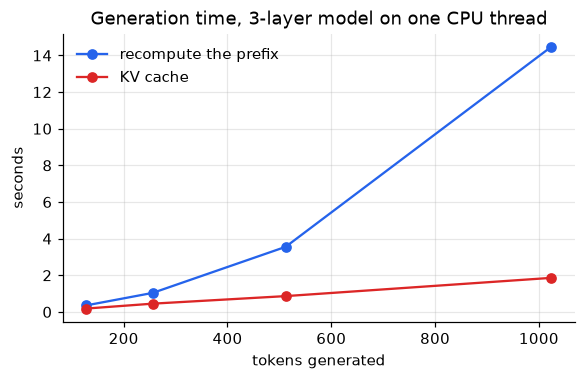

In [6]:
lengths, t_full, t_cache = [128, 256, 512, 1024], [], []
for n in lengths:
    for use_cache, times in [(False, t_full), (True, t_cache)]:
        t0 = time.perf_counter()
        generate(char_lm, prompt, n, use_cache=use_cache, temperature=0)
        times.append(time.perf_counter() - t0)
    print(f"{n:5d} tokens: recompute {t_full[-1]:5.2f}s, KV cache {t_cache[-1]:4.2f}s, speedup {t_full[-1] / t_cache[-1]:.1f}x")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(lengths, t_full, marker="o", label="recompute the prefix")
ax.plot(lengths, t_cache, marker="o", label="KV cache")
ax.set(xlabel="tokens generated", ylabel="seconds", title="Generation time, 3-layer model on one CPU thread")
ax.legend(frameon=False);

#### Experiment: greedy, temperature, top-k and top-p

For each decoding rule we generate 64 continuations of 56 characters from the same prompt (staying inside the 64-character context the model was trained on). We score two things. **Diversity** is the fraction of 8-character substrings that are distinct, across all 64 samples: a decoder that repeats itself scores low. **Real-word rate** is the fraction of generated words that appear somewhere in the training text, a rough proxy for quality.

In [7]:
vocabulary = set(re.findall(r"[a-z]+", tok.decode(train_ids).lower()))
rules = {
    "greedy": dict(temperature=0),
    "T = 0.5": dict(temperature=0.5),
    "T = 1.0": dict(temperature=1.0),
    "T = 1.5": dict(temperature=1.5),
    "top-k = 5": dict(temperature=1.0, top_k=5),
    "top-p = 0.8": dict(temperature=1.0, top_p=0.8),
}
decoding = {}
for name, args in rules.items():
    out = generate(char_lm, prompt.repeat(64, 1), 56, generator=torch.Generator().manual_seed(0), **args)
    samples = [tok.decode(row[prompt.shape[1]:]) for row in out]
    words = [w for s in samples for w in re.findall(r"[a-z]+", s.lower())]
    grams = [s[i:i + 8] for s in samples for i in range(len(s) - 7)]
    decoding[name] = (len(set(grams)) / len(grams), sum(w in vocabulary for w in words) / len(words))
    print(f"{name:12s} distinct 8-grams {decoding[name][0]:.2f}   real words {decoding[name][1]:.2f}   {samples[1][:48]!r}")

greedy       distinct 8-grams 0.01   real words 1.00   'The shall the shall the shall the shall the come'


T = 0.5      distinct 8-grams 0.89   real words 0.89   'The king and the rown comine her man her his mor'


T = 1.0      distinct 8-grams 1.00   real words 0.68   'Thou lour none, arbeence in\nThe prone this semet'


T = 1.5      distinct 8-grams 1.00   real words 0.43   'Pron:\nFeran neop: but couibutield Fnect heasemor'


top-k = 5    distinct 8-grams 0.96   real words 0.82   'Thou lour a propt his couty: he shall the will t'


top-p = 0.8  distinct 8-grams 0.97   real words 0.87   'Thou lord not heard that is the pronest hear mor'


#### Why it worked: a post-mortem

**Greedy decoding loops.** All 64 greedy samples are the same string, and inside it "the shall" repeats, so only 1% of its 8-grams are distinct. Once a phrase has appeared, the model gives repeating it a high probability, so the most likely continuation of a loop is more loop. Holtzman et al. (2020) showed the same degeneration in GPT-2, and that beam search, which searches harder for the single most likely text, makes it worse. **[established]**

**Temperature trades quality for diversity.** Lower temperature gives more real words and fewer distinct strings; higher temperature the reverse (real-word rate 0.89 at `\(T = 0.5\)`, 0.68 at `\(T = 1\)`, 0.43 at `\(T = 1.5\)`). At `\(T = 1.5\)` the flattened distribution gives so much mass to the long tail of unlikely characters that the text falls apart. **[established]**

**Truncation keeps most of the diversity and cuts the junk.** Top-k and top-p sample at `\(T = 1\)` but drop the tail, and they score clearly higher on real words than plain `\(T = 1\)` (0.82 and 0.87 against 0.68) while staying almost as diverse (0.96 and 0.97 distinct 8-grams). The tail is where the model is least reliable: each of those tokens is individually unlikely, but together they are drawn often. **[established]**

**The cache turns quadratic work into linear work.** The speedup grows with length, from 1.9&times; at 128 tokens to 7.8&times; at 1,024, because recomputation repeats ever longer prefixes. Real systems pay for this in memory: the cache holds two vectors per layer per token, which is why long contexts are memory-bound and why chapter 4's grouped-query attention, which shares keys and values between heads, exists. **[established]**

### Step 2 (major): chain of thought, a scratchpad as working memory

#### The problem before

A Transformer with `\(L\)` layers computes each next token with a fixed pipeline of `\(L\)` blocks. However hard the question, the answer token gets the same amount of serial computation. Some problems need many steps that each depend on the last. Adding up a list of numbers, following a chain of reasoning or tracking the state of a program cannot be finished in `\(L\)` parallel operations once the chain is longer than the network is deep.

#### The idea

Let the model write the intermediate results as tokens. Each written token is fed back in as input, so the next forward pass starts from a result the previous pass already computed. Nye et al. (2021) trained small models to emit such **scratchpads** for addition and program execution, and Wei et al. (2022) found that very large models do the same when the prompt shows a few worked examples, which they called **chain-of-thought prompting**. Theory agrees: with a polynomial number of intermediate tokens, a Transformer can carry out any efficient sequential computation, while without them it is limited to much shallower circuits (Merrill and Sabharwal, 2024; Feng et al., 2023). **[likely]**, since these results bound what is expressible, not what training finds.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: serial computation grows with the tokens written</p><div class="mlx-eq">$$\text{serial steps available for the answer} \;\approx\; \underbrace{L}_{\text{direct answer}} \quad\longrightarrow\quad \underbrace{L \times (k + 1)}_{\text{after } k \text{ written steps}}$$</div><p class="mlx-eq__where">Inside one forward pass the depth is \(L\). A token written at step \(j\) is read back at step \(j + 1\), so the computation can chain through every written token before the answer.</p></div>

#### The task

We use a task with an obvious serial structure: **the last digit of the sum of `\(n\)` digits**, for `\(n\)` from 2 to 8. Each digit carries a letter name (`a`, `b`, `c`, ...), so the question `3a5b7c2d=` means a = 3, b = 5, c = 7, d = 2, and the answer is the last digit of 17, which is 7. The names let a model look a digit up by content, the way a program reads a variable. The two formats differ only in what the model writes after `=`:

- **direct:** `7.`, the answer straight away;
- **chain of thought:** `a3b8c5d7>7.`, the running sum after each digit, then the answer.

Both use the same question, the same model (2 layers, width 64, about 100k parameters) and the same 1,000 training steps.

In [8]:
VOCAB = "0123456789abcdefgh=>.[]#"  # digits, digit names, punctuation, padding
stoi = {c: i for i, c in enumerate(VOCAB)}
PAD, NAMES, NMAX = stoi["#"], "abcdefgh", 8


def question(digits):
    return "".join(f"{d}{NAMES[i]}" for i, d in enumerate(digits)) + "="


def running_sums(digits):
    total, steps = 0, ""
    for i, d in enumerate(digits):
        total = (total + d) % 10
        steps += f"{NAMES[i]}{total}"
    return steps, total


def direct_example(digits):
    _, answer = running_sums(digits)
    return [(question(digits), False), (f"{answer}.", True)]  # (text, is it trained on?)


def cot_example(digits):
    steps, answer = running_sums(digits)
    return [(question(digits), False), (f"{steps}>{answer}.", True)]


print("direct:", "".join(t for t, _ in direct_example([3, 5, 7, 2])))
print("chain: ", "".join(t for t, _ in cot_example([3, 5, 7, 2])))

direct: 3a5b7c2d=7.
chain:  3a5b7c2d=a3b8c5d7>7.


Every example is a list of text segments with a flag saying whether the model is trained to produce it. The question is never a training target, only the completion. (Step 4 uses the flag to skip text inserted by a tool.) The training loop is the chapter 1 recipe: AdamW, warmup, cosine decay.

In [9]:
def make_batch(make_example, batch_size, rng):
    width = 6 * NMAX + 8
    x = torch.full((batch_size, width), PAD)
    y = torch.full((batch_size, width), -100)  # -100: no loss at this position
    for b in range(batch_size):
        digits = [rng.randrange(10) for _ in range(rng.randint(2, NMAX))]
        ids, trained = [], []
        for text, is_target in make_example(digits):
            ids += [stoi[c] for c in text]
            trained += [is_target] * len(text)
        x[b, :len(ids)] = torch.tensor(ids)
        for j in range(len(ids) - 1):
            if trained[j + 1]:
                y[b, j] = ids[j + 1]  # predict token j+1 from tokens up to j
    return x, y


def train_task(make_example, steps=1000, lr=3e-3, seed=0):
    torch.manual_seed(seed)
    rng = random.Random(seed)
    model = TransformerLM(len(VOCAB), dim=64, n_layers=2, n_heads=4)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)
    start, model.loss_curve = time.time(), []
    for step in range(steps):
        warm, cosine = min(1, (step + 1) / 100), 0.5 * (1 + math.cos(math.pi * step / steps))
        for group in opt.param_groups:
            group["lr"] = lr * warm * (0.1 + 0.9 * cosine)
        x, y = make_batch(make_example, 64, rng)
        logits, _ = model(x)
        loss = F.cross_entropy(logits.flatten(0, 1), y.flatten(), ignore_index=-100)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if (step + 1) % 50 == 0:
            model.loss_curve.append(loss.item())
    print(f"{mlexp.count_params(model):,} parameters, final loss {loss.item():.3f}, {time.time() - start:.0f}s")
    return model.eval()


def solve(model, prompts, n_new, **pick_args):
    """Batched generation for prompts of equal length; returns the text up to the first '.'."""
    idx = torch.tensor([[stoi[c] for c in p] for p in prompts])
    out = generate(model, idx, n_new, **pick_args)[:, idx.shape[1]:]
    return ["".join(VOCAB[i] for i in row).split(".")[0] for row in out.tolist()]


def final_answer(text):
    return text.split(">")[-1]


def test_set(n, size=300, seed=100):
    rng = random.Random(seed + n)
    return [[rng.randrange(10) for _ in range(n)] for _ in range(size)]

#### Experiment: answer directly, or write the steps first?

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">Both models see the same questions and train for the same number of steps. The chain-of-thought model must produce up to 19 tokens where the direct model produces 2, so it has more to learn and more chances to slip. How do you expect the two to compare as the number of digits grows from 2 to 8?</p><details><summary>Show what happened</summary><p>The direct model gets every 2-digit question right, 47% of 3-digit ones, and is at chance (10%) from 4 digits on. The chain-of-thought model is at 100% for every length up to 8.</p></details></div>

101,440 parameters, final loss 0.969, 85s


101,440 parameters, final loss 0.002, 89s
n = 2: direct 1.00, chain of thought 1.00
n = 3: direct 0.47, chain of thought 1.00


n = 4: direct 0.13, chain of thought 1.00
n = 5: direct 0.12, chain of thought 1.00


n = 6: direct 0.07, chain of thought 1.00
n = 7: direct 0.08, chain of thought 1.00


n = 8: direct 0.10, chain of thought 1.00
chain-of-thought training loss every 100 steps: 0.76 0.70 0.74 0.70 0.44 0.00 0.00 0.00 0.00 0.00
example chain: a3b8c5d7e6f5g6h0>0


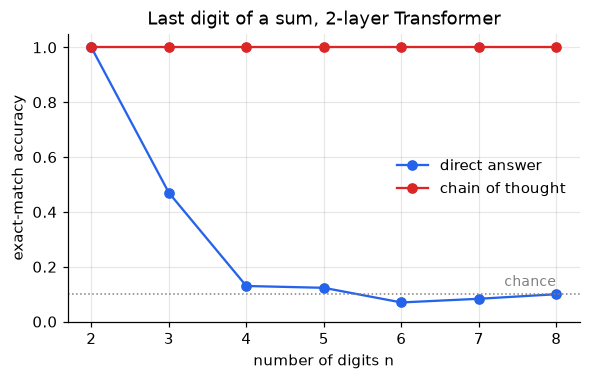

In [10]:
direct_model = train_task(direct_example)
cot_model = train_task(cot_example)

ns = list(range(2, NMAX + 1))
accuracy = {"direct answer": [], "chain of thought": []}
for n in ns:
    problems = test_set(n)
    gold = [str(running_sums(d)[1]) for d in problems]
    prompts = [question(d) for d in problems]
    for name, model, n_new in [("direct answer", direct_model, 2), ("chain of thought", cot_model, 2 * n + 3)]:
        answers = [final_answer(t) for t in solve(model, prompts, n_new, temperature=0)]
        accuracy[name].append(np.mean([a == g for a, g in zip(answers, gold)]))
    print(f"n = {n}: direct {accuracy['direct answer'][-1]:.2f}, chain of thought {accuracy['chain of thought'][-1]:.2f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
for name, acc in accuracy.items():
    ax.plot(ns, acc, marker="o", label=name)
ax.axhline(0.1, color="gray", ls=":", lw=1)
ax.text(8, 0.13, "chance", ha="right", color="gray", fontsize=9)
ax.set(xlabel="number of digits n", ylabel="exact-match accuracy", ylim=(0, 1.05),
       title="Last digit of a sum, 2-layer Transformer")
ax.legend(frameon=False);
print("chain-of-thought training loss every 100 steps:", " ".join(f"{l:.2f}" for l in cot_model.loss_curve[1::2]))
print("example chain:", solve(cot_model, [question([3, 5, 7, 2, 9, 9, 1, 4])], 19, temperature=0)[0])

#### Why it worked: a post-mortem

**The direct model fails because the answer needs more serial steps than it has.** To answer `\(n\)` digits in one pass, the model must combine all of them inside two layers. For two digits that is one lookup in a 10 by 10 table, and the model learns it perfectly. With three digits it is right 47% of the time, and from four digits on it is at chance (7% to 13%) within our training budget. A deeper or longer-trained model would handle a few more digits, but the depth needed grows with `\(n\)`, so any fixed depth runs out. **[likely]**: the theory says a fixed-depth Transformer cannot do this kind of iterated computation for all lengths, and our run shows where a small one gives up.

**The chain-of-thought model turns one hard problem into many easy ones.** At every step it does the same small job: find the digit named by the letter it just wrote, add it to the running total it wrote one token earlier, and keep the last digit. That job needs the same two attention lookups and one table lookup whatever `\(n\)` is, so a 2-layer model can do it, and the chain carries the state from one step to the next. This is what "working memory" means here: the written tokens hold the state that the fixed-depth network cannot hold internally. **[established]** for this kind of task, matching Nye et al. (2021).

**Learning it is not gradual.** The chain-of-thought training loss printed above sits on a plateau for hundreds of steps and then falls almost to zero within about a hundred, between steps 400 and 600. Before the drop the model writes well-formed chains with the wrong digits; after it, it has learned to look up the digit named by each letter. That is the same sudden "induction head" transition seen in larger models. **[likely]**

**What our toy does not show.** In real models, chain of thought often helps only above a certain scale (Wei et al., 2022), and the written steps are not always the computation the model actually uses (Turpin et al., 2023). Our model was trained on exactly the steps it writes, so its chain is faithful by construction.

### Step 3 (major): test-time compute, sample many and verify

#### The idea

If one chain can be wrong, sample several. **Self-consistency** (Wang et al., 2022) samples many chains at a temperature above zero and takes the majority vote of their final answers. It helps because a correct chain usually reaches the same answer, while wrong chains go wrong in different ways and scatter their votes. **Best-of-N with a verifier** (Cobbe et al., 2021) instead keeps a chain that a separate checker accepts. A verifier helps even when most chains are wrong, as long as one is right and the checker can recognize it. Reasoning models since 2024 combine both ideas with long traces trained by reinforcement learning, and their accuracy keeps rising with the compute spent at test time (Snell et al., 2024). **[established]**

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: coverage from N independent samples</p><div class="mlx-eq">$$P(\text{at least one of } N \text{ samples is right}) = 1 - (1 - p)^N$$</div><p class="mlx-eq__where">\(p\) is the accuracy of a single sample. A perfect verifier reaches this coverage; a majority vote needs more, because the right answer must also be the most common one.</p></div>

#### A reasoner that slips

Our chain-of-thought model is perfect with greedy decoding, so there is nothing to search for. To see search at work we need a model that makes mistakes. Instead of training a worse model, we sample the same one at temperature 1.75 on 8-digit questions, which makes it slip at individual steps. Each slip corrupts the running total, so a sampled chain reaches the right answer only some of the time. Our **verifier** recomputes every running total in the chain and accepts the chain only if all of them are right. It does not know the answer in advance, but on this task checking the steps is as easy as solving the problem. In real tasks, verifiers are unit tests, proof checkers, or a second trained model, and they are rarely this reliable.

In [11]:
def verify(digits, chain):
    """Accept a chain only if every running total and the final answer are correct."""
    steps, answer = running_sums(digits)
    return chain == f"{steps}>{answer}"


n, N_MAX, TEMP = 8, 32, 1.75
problems = test_set(n, seed=7)
gold = [str(running_sums(d)[1]) for d in problems]
prompts = [question(d) for d in problems for _ in range(N_MAX)]  # every question N_MAX times
t0 = time.time()
chains = solve(cot_model, prompts, 2 * n + 3, temperature=TEMP, generator=torch.Generator().manual_seed(0))
chains = [chains[i * N_MAX:(i + 1) * N_MAX] for i in range(len(problems))]
print(f"sampled {len(prompts):,} chains in {time.time() - t0:.0f}s (with the KV cache)")
print("one question, five samples:", chains[0][:5], " correct answer:", gold[0])

sampled 9,600 chains in 7s (with the KV cache)
one question, five samples: ['a8b8cf1>1', 'a3b3c1d1e3f6g6a0b3c', 'a3]b3cf6>6', 'a3b3d3e5>5', 'a3b3c15d5e2g5>5']  correct answer: 6


#### Experiment: accuracy as a function of the number of samples

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">A single noisy sample is right about 30% of the time. With 32 samples per question, which does better, the majority vote or the verifier, and does either get close to 100%?</p><details><summary>Show what happened</summary><p>Both improve steadily. Both reach the 90s, but the verifier gets there much sooner: 89% with 8 samples, where the vote is at 59%. With 32 samples the verifier is at 100% and the vote at 94%. The vote needs the right answer to be the most common one, which takes many samples.</p></details></div>

N =  1: majority vote 0.30, verifier 0.30, bound 1-(1-p)^N 0.30
N =  2: majority vote 0.30, verifier 0.46, bound 1-(1-p)^N 0.51
N =  4: majority vote 0.38, verifier 0.70, bound 1-(1-p)^N 0.76
N =  8: majority vote 0.59, verifier 0.89, bound 1-(1-p)^N 0.94
N = 16: majority vote 0.79, verifier 0.98, bound 1-(1-p)^N 1.00
N = 32: majority vote 0.94, verifier 1.00, bound 1-(1-p)^N 1.00


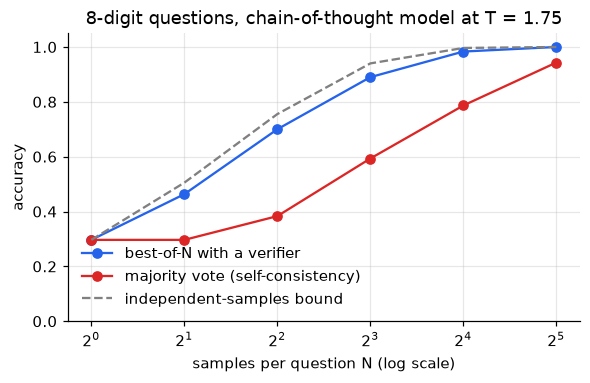

In [12]:
Ns = [1, 2, 4, 8, 16, 32]
single = np.mean([final_answer(c[0]) == g for c, g in zip(chains, gold)])
vote, verified = [], []
for N in Ns:
    v_ok = r_ok = 0
    for digits, cs, g in zip(problems, chains, gold):
        answers = [final_answer(c) for c in cs[:N]]
        v_ok += collections.Counter(answers).most_common(1)[0][0] == g
        accepted = [c for c in cs[:N] if verify(digits, c)]
        r_ok += (final_answer(accepted[0]) if accepted else answers[0]) == g
    vote.append(v_ok / len(problems))
    verified.append(r_ok / len(problems))
    print(f"N = {N:2d}: majority vote {vote[-1]:.2f}, verifier {verified[-1]:.2f}, bound 1-(1-p)^N {1 - (1 - single) ** N:.2f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(Ns, verified, marker="o", label="best-of-N with a verifier")
ax.plot(Ns, vote, marker="o", label="majority vote (self-consistency)")
ax.plot(Ns, [1 - (1 - single) ** N for N in Ns], ls="--", color="gray", label="independent-samples bound")
ax.set_xscale("log", base=2)
ax.set(xlabel="samples per question N (log scale)", ylabel="accuracy", ylim=(0, 1.05),
       title=f"8-digit questions, chain-of-thought model at T = {TEMP}")
ax.legend(frameon=False);

#### Why it worked: a post-mortem

**Both curves rise with N, which is the point of test-time compute.** Without changing a single weight, accuracy goes from 30% with one sample to 94% (vote) and 100% (verifier) with 32, at 32 times the generation cost. This is the trade that reasoning models make at scale. **[established]**

**The verifier wins because it only needs one good chain.** Its curve tracks the bound `\(1 - (1 - p)^N\)`, slightly below it (0.89 against 0.94 at N = 8) because samples of the same question are not fully independent: a question with an awkward digit pattern is hard for every sample. The vote needs the right answer to be the single most common one. With one sample right 30% of the time and nine wrong answers to scatter over, it needs many samples before the right answer reliably comes out on top. **[established]**, matching the gap between verifier-based and voting methods reported by Cobbe et al. (2021) and later work.

**Our verifier is too good to be true.** Checking a running sum is as easy as computing it, so this verifier is close to an oracle. Real verifiers are learned reward models or partial checks, and a policy that is searched hard against a learned verifier finds its blind spots, a form of reward hacking. That is why the strongest gains come in domains with exact checkers, such as mathematics with known answers and code with tests. **[likely]**

**Sampling noise is not the only source of errors.** We created mistakes with a high temperature. In real models, many errors come from a confidently wrong first step that every sample repeats. Voting cannot fix those; it only helps when the errors differ between samples. **[likely]**

### Step 4 (minor): tool use, a calculator in the loop

#### The idea

Some work is better done outside the network. Toolformer (Schick et al., 2023) taught a model to write API calls such as `[Calculator(400/1400)]` in its own text; the harness that runs the model pauses, executes the call and pastes the result into the context, and generation continues. ReAct (Yao et al., 2022) interleaves such actions with written reasoning, which is the basic loop of today's agents: think, call a tool, read the result, repeat.

We train a third model on our task with a calculator. The model copies the question into a call such as `[3a5b7c2d]`. When it writes `]`, the harness adds up the digits and inserts `17>`, and the model finishes with `7.`. The inserted text is excluded from the loss, so the model is never trained to compute the sum itself.

In [13]:
def tool_example(digits):
    q = question(digits)
    return [(q, False), ("[" + q[:-1] + "]", True),           # the model writes the call
            (f"{sum(digits)}>", False),                        # the harness inserts the result
            (f"{sum(digits) % 10}.", True)]                    # the model reads it off


@torch.no_grad()
def run_with_tools(model, prompt, use_tool=True, max_len=40):
    """The agent loop: generate greedily; whenever the model closes a call, run the calculator."""
    ids, text = [stoi[c] for c in prompt], ""
    while len(text) < max_len and not text.endswith("."):
        logits, _ = model(torch.tensor([ids]))
        token = VOCAB[logits[0, -1].argmax().item()]
        text += token
        ids.append(stoi[token])
        if token == "]" and use_tool:
            call = text[text.rindex("[") + 1:-1]
            result = f"{sum(int(c) for c in call if c.isdigit())}>"
            text += result
            ids += [stoi[c] for c in result]
    return text


tool_model = train_task(tool_example)
print(run_with_tools(tool_model, question([3, 5, 7, 2])))
for n in [2, 4, 6, 8]:
    problems = test_set(n, size=100)
    row = []
    for use_tool in (True, False):
        answers = [run_with_tools(tool_model, question(d), use_tool).rstrip(".").split(">")[-1] for d in problems]
        row.append(np.mean([a == str(sum(d) % 10) for a, d in zip(answers, problems)]))
    print(f"n = {n}: with the calculator {row[0]:.2f}, calculator switched off {row[1]:.2f}")
print("switched off:", run_with_tools(tool_model, question([3, 5, 7, 2]), use_tool=False))

101,440 parameters, final loss 0.001, 88s
[3a5b7c2d]17>7.


n = 2: with the calculator 1.00, calculator switched off 0.00


n = 4: with the calculator 1.00, calculator switched off 0.00


n = 6: with the calculator 1.00, calculator switched off 0.00


n = 8: with the calculator 1.00, calculator switched off 0.00
switched off: [3a5b7c2d]d3e]d5e]e]f5g3h]5d3e5f5g5h]f5g


#### Why it worked: a post-mortem

**With the calculator the model is perfect at every length,** because its only jobs are to copy the question into a call and read off the last digit of the result. Both are easy for attention, and neither gets harder as `\(n\)` grows. **[established]**

**Without the calculator it is helpless,** at 0% for every length. It has never been trained to produce a result, so when nothing is inserted it does not know how to continue. The skill lives in the harness, not in the weights. This is the trade tool use makes: exact, up-to-date results for anything a tool can compute, at the price of depending on the tool being there and on the model calling it correctly. **[established]**

**Our toy skips the hard part.** Here every training example shows exactly where to call the tool. Toolformer's contribution was learning *where* calls help without such labels: it inserted candidate calls into ordinary text and kept the ones that made the following tokens easier to predict. Deciding when to call which tool, and recovering when a call fails, is what makes real agents hard. **[likely]**

## Across three seeds

The numbers on this page come from one run, seed 0. We reran the whole notebook twice more with every random seed shifted by 1 and by 2, which changes the initial weights, the batches and the evaluation samples (the `Seed runs` workflow in the repository does this for any chapter). A gap between two runs means something only when it is clearly larger than their spread.

| Run | This page (seed 0) | Mean ± sd, 3 seeds | Seeds 0 / 1 / 2 |
| --- | --- | --- | --- |
| Direct answer, n = 3 | 0.47 | 0.45 ± 0.02 | 0.47 / 0.46 / 0.43 |
| Chain of thought, n = 3 | 1.00 | 1.00 ± 0.00 | 1.00 / 1.00 / 1.00 |
| Direct answer, n = 6 | 0.07 | 0.09 ± 0.02 | 0.07 / 0.10 / 0.09 |
| Majority vote, N = 8 | 0.59 | 0.65 ± 0.06 | 0.59 / 0.71 / 0.64 |
| Verifier, N = 8 | 0.89 | 0.90 ± 0.02 | 0.89 / 0.92 / 0.90 |

Every result held in all three seeds: the direct model at about 45% on 3 digits and at chance beyond, chain of thought at 100%, and the verifier well ahead of the vote.

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Implement greedy, temperature, top-k and top-p decoding, and explain why greedy text loops.</li><li>Build a KV cache and explain why it turns quadratic generation cost into linear cost.</li><li>Explain, in terms of serial depth, why writing intermediate steps lets a fixed-depth Transformer solve longer problems.</li><li>Compare majority voting with best-of-N verification, and wire a tool call into the generation loop.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>Why can a KV cache store keys and values but not the attention outputs of past tokens?</summary><p>In a causal model, a past token's keys and values depend only on tokens up to it, so they never change. Its attention output also never changes, but the new token does not need it: it needs only its own query against all past keys and values. What must be computed fresh is the new token's query, key and value at every layer.</p></details><details><summary>Our direct model answered 2-digit questions perfectly, but only about half of 3-digit ones and was at chance from 4 digits on. Why does writing the running sums fix that, and what is the cost?</summary><p>Each written running sum is read back by the next forward pass, so each pass only has to add one digit to a total it can see. The work per pass stays constant as n grows. The cost is about 2n + 3 forward passes per answer instead of 2, so inference gets longer and more expensive.</p></details><details><summary>When does majority voting fail to help, even with many samples?</summary><p>When the model's errors are shared rather than random. If most samples make the same mistake, the wrong answer wins the vote. Voting helps only when the right answer is more common than any single wrong answer.</p></details></div>

## Further reading

- Holtzman et al., 2020, [The Curious Case of Neural Text Degeneration](https://arxiv.org/abs/1904.09751): why greedy and beam search loop, and nucleus sampling.
- Nye et al., 2021, [Show Your Work: Scratchpads for Intermediate Computation with Language Models](https://arxiv.org/abs/2112.00114).
- Wei et al., 2022, [Chain-of-Thought Prompting Elicits Reasoning in Large Language Models](https://arxiv.org/abs/2201.11903).
- Wang et al., 2022, [Self-Consistency Improves Chain of Thought Reasoning in Language Models](https://arxiv.org/abs/2203.11171).
- Cobbe et al., 2021, [Training Verifiers to Solve Math Word Problems](https://arxiv.org/abs/2110.14168): GSM8K and best-of-N with a learned verifier.
- Merrill and Sabharwal, 2024, [The Expressive Power of Transformers with Chain of Thought](https://arxiv.org/abs/2310.07923).
- Yao et al., 2022, [ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629), and Schick et al., 2023, [Toolformer: Language Models Can Teach Themselves to Use Tools](https://arxiv.org/abs/2302.04761).
- DeepSeek-AI, 2025, [DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning](https://arxiv.org/abs/2501.12948): long reasoning traces learned with reinforcement learning.